In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sleep_health_and_lifestyle_dataset.csv to Sleep_health_and_lifestyle_dataset.csv


In [ ]:
import pandas as pd
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [ ]:
df = df.drop_duplicates()
df['Sleep Disorder'] = df['Sleep Disorder'].fillna("None")
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [ ]:
# Check missing values
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [ ]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna("None")

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.columns

Index(['Person_ID', 'Gender', 'Age', 'Occupation', 'Sleep_Duration',
       'Quality_of_Sleep', 'Physical_Activity_Level', 'Stress_Level',
       'BMI_Category', 'Blood_Pressure', 'Heart_Rate', 'Daily_Steps',
       'Sleep_Disorder'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person_ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep_Duration           374 non-null    float64
 5   Quality_of_Sleep         374 non-null    int64  
 6   Physical_Activity_Level  374 non-null    int64  
 7   Stress_Level             374 non-null    int64  
 8   BMI_Category             374 non-null    object 
 9   Blood_Pressure           374 non-null    object 
 10  Heart_Rate               374 non-null    int64  
 11  Daily_Steps              374 non-null    int64  
 12  Sleep_Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


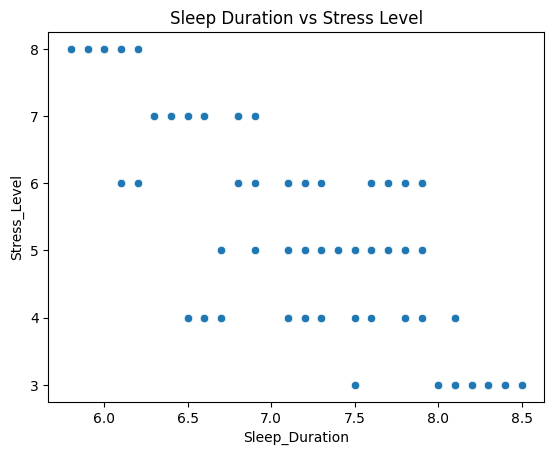

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df['Sleep_Duration'], y=df['Stress_Level'])
plt.title("Sleep Duration vs Stress Level")
plt.show()

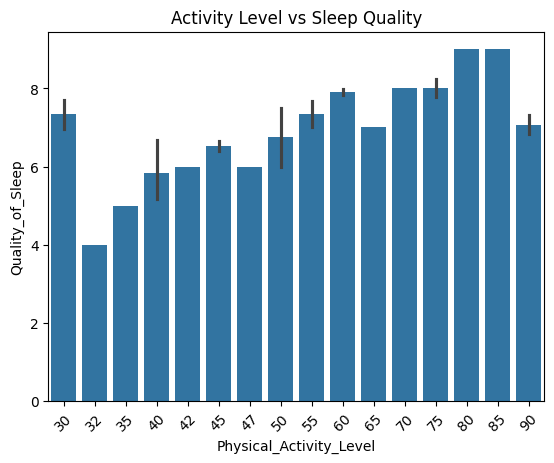

In [ ]:
sns.barplot(x=df['Physical_Activity_Level'], y=df['Quality_of_Sleep'])
plt.xticks(rotation=45)
plt.title("Activity Level vs Sleep Quality")
plt.show()

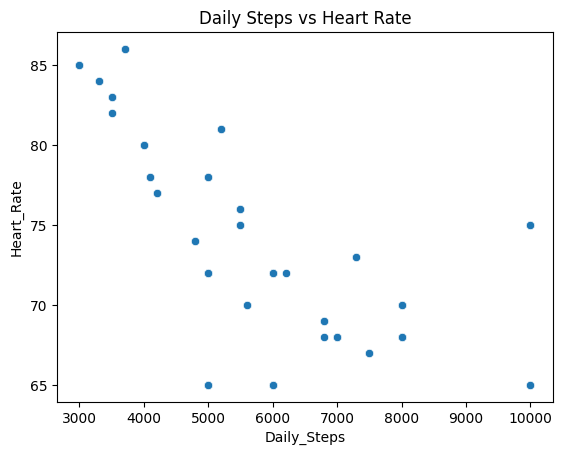

In [ ]:
sns.scatterplot(x=df['Daily_Steps'], y=df['Heart_Rate'])
plt.title("Daily Steps vs Heart Rate")
plt.show()

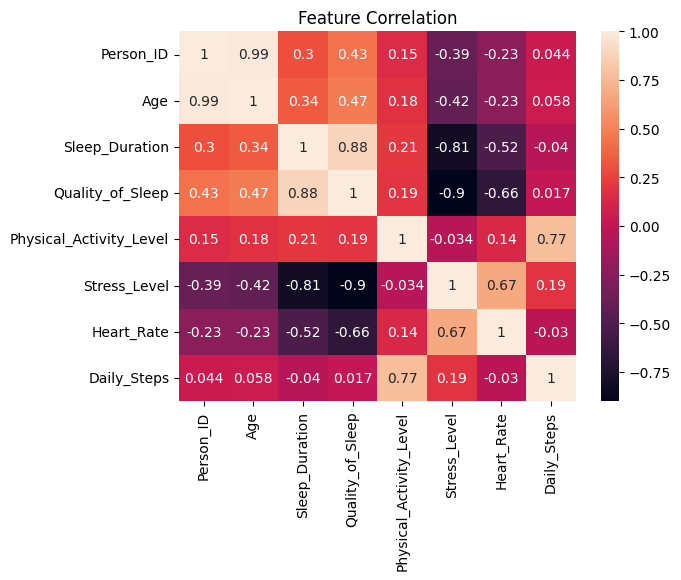

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation")
plt.show()

In [ ]:
df.groupby('Sleep_Duration')['Stress_Level'].mean().sort_values().head(10)

,Stress_Level
Sleep_Duration,
8.3,3.000000
8.4,3.000000
8.0,3.000000
8.5,3.000000
8.2,3.000000
8.1,3.133333
7.5,4.000000
6.7,4.400000
7.2,4.472222


In [ ]:
df.groupby('Physical_Activity_Level')['Quality_of_Sleep'].mean()

,Quality_of_Sleep
Physical_Activity_Level,
30,7.352941
32,4.000000
35,5.000000
40,5.833333
42,6.000000
45,6.529412
47,6.000000
50,6.750000
55,7.333333


In [ ]:
df.groupby(['Sleep_Duration','Stress_Level']).size().reset_index(name='Count')

,Sleep_Duration,Stress_Level,Count
0,5.8,8,2
1,5.9,8,4
2,6.0,8,31
3,6.1,6,2
4,6.1,8,23
5,6.2,6,2
6,6.2,8,10
7,6.3,7,13
8,6.4,7,9
9,6.5,4,8


In [ ]:
df.groupby('BMI_Category')['Quality_of_Sleep'].mean()

,Quality_of_Sleep
BMI_Category,
Normal,7.661538
Normal Weight,7.428571
Obese,6.400000
Overweight,6.898649


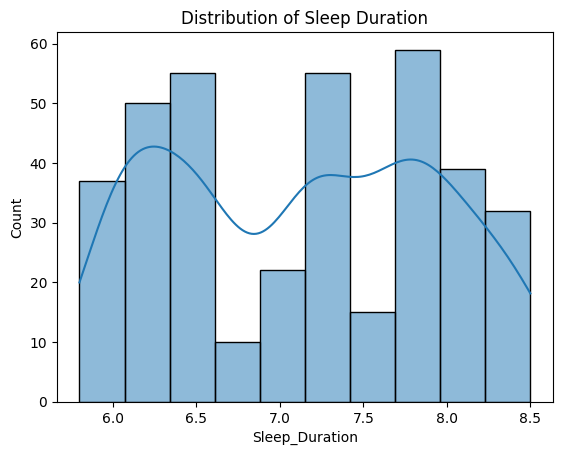

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Sleep_Duration'], kde=True)
plt.title("Distribution of Sleep Duration")
plt.show()

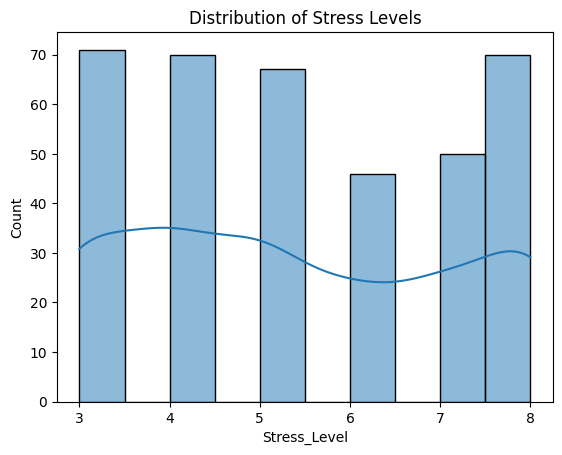

In [ ]:
sns.histplot(df['Stress_Level'], kde=True)
plt.title("Distribution of Stress Levels")
plt.show()

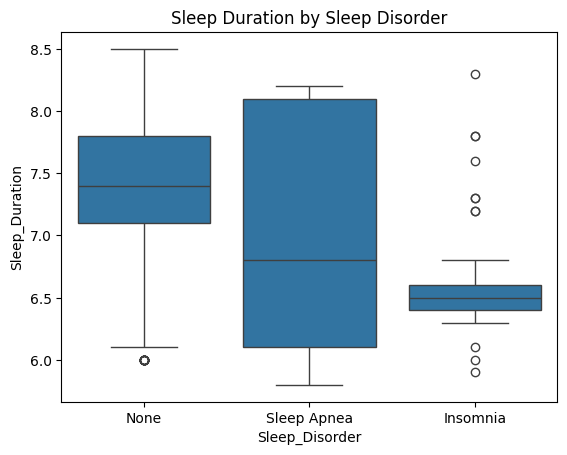

In [ ]:
sns.boxplot(x=df['Sleep_Disorder'], y=df['Sleep_Duration'])
plt.title("Sleep Duration by Sleep Disorder")
plt.show()

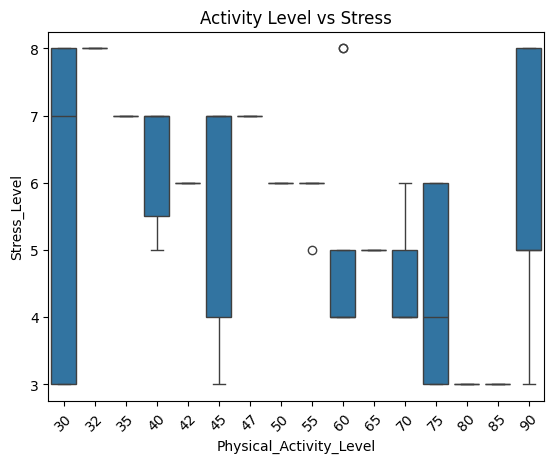

In [ ]:
sns.boxplot(x=df['Physical_Activity_Level'], y=df['Stress_Level'])
plt.xticks(rotation=45)
plt.title("Activity Level vs Stress")
plt.show()

In [ ]:
# Normalize and compute risk score properly

df['risk_score'] = (
    (df['Stress_Level'] / 10) * 0.35 +                 # Higher stress = higher risk
        ((10 - df['Sleep_Duration']) / 10) * 0.25 +        # Less sleep = higher risk
            ((10000 - df['Daily_Steps']) / 10000) * 0.20 +     # Fewer steps = higher risk
                ((100 - df['Physical_Activity_Level']) / 100) * 0.20  # Less activity = higher risk
                )

In [ ]:
def risk_category(score):
      if score < 0.33:
              return "Low Risk"
      elif score < 0.66:
         return "Moderate Risk"
      else:
         return "High Risk"
         df['Risk_Category'] = df['risk_score'].apply(risk_category)

In [ ]:
print(df.columns)

Index(['Person_ID', 'Gender', 'Age', 'Occupation', 'Sleep_Duration',
       'Quality_of_Sleep', 'Physical_Activity_Level', 'Stress_Level',
       'BMI_Category', 'Blood_Pressure', 'Heart_Rate', 'Daily_Steps',
       'Sleep_Disorder', 'risk_score'],
      dtype='object')


In [ ]:
def risk_category(score):
      if score < 0.33:
              return "Low Risk"
      elif score < 0.66:
              return "Moderate Risk"
      else:
              return "High Risk"


In [ ]:
print(df.columns)

Index(['Person_ID', 'Gender', 'Age', 'Occupation', 'Sleep_Duration',
       'Quality_of_Sleep', 'Physical_Activity_Level', 'Stress_Level',
       'BMI_Category', 'Blood_Pressure', 'Heart_Rate', 'Daily_Steps',
       'Sleep_Disorder', 'risk_score'],
      dtype='object')


In [ ]:
df[['Sleep_Duration','Stress_Level','Daily_Steps',
    'Physical_Activity_Level','risk_score','Blood_Pressure']].head()

,Sleep_Duration,Stress_Level,Daily_Steps,Physical_Activity_Level,risk_score,Blood_Pressure
0,6.1,6,4200,42,0.5395,126/83
1,6.2,8,10000,60,0.4550,125/80
2,6.2,8,10000,60,0.4550,125/80
3,5.9,8,3000,30,0.6625,140/90
4,5.9,8,3000,30,0.6625,140/90


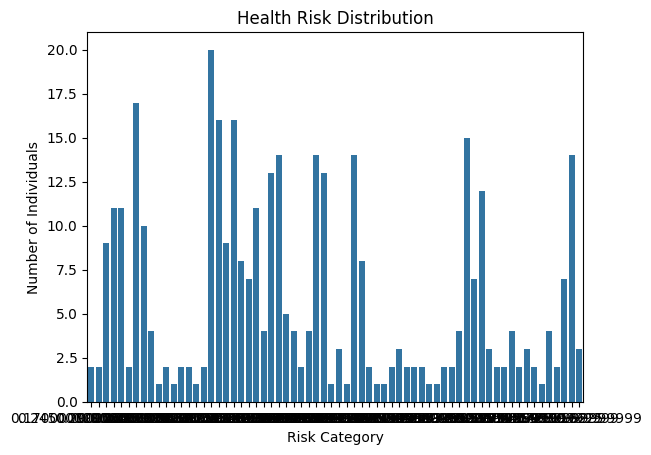

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='risk_score', data=df)
plt.title("Health Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Individuals")
plt.show()

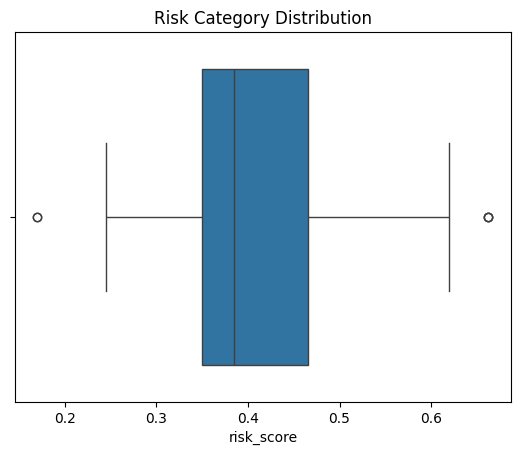

In [ ]:
sns.boxplot(x=df['risk_score'])
plt.title("Risk Category Distribution")
plt.show()